In [1]:
import os

print(os.listdir("/kaggle/input/"))



['trial-data', 'jigsawmultilingualtoxiccommentclassification', 'datasets', 'test-data', 'train-data']


In [7]:
# ============================================================
# HYBRID EXPLAINABLE TOXICITY DETECTION — FULLY CORRECTED
# Architecture:
#   Stage 0 : Transfer Learning  — fine-tune BERT on Jigsaw
#   Stage 1 : Hierarchical Attention Classification Head
#   Stage 2 : Co-Attention + BIO Span Tagging Head
#             (I-token collapse fully fixed)
# ============================================================


# ─────────────────────────────────────────────────────────────
# CELL 1 — Imports & Setup
# ─────────────────────────────────────────────────────────────
# Add after BERT_PATH is set
import os
tokenizer_json = os.path.join(BERT_PATH, "tokenizer.json")
if not os.path.exists(tokenizer_json):
    print("  ⚠️  tokenizer.json missing — fast tokenizer may not load.")
    print("  💡 Add 'bert-base-uncased' from HuggingFace datasets on Kaggle,")
    print("     or run: !pip install transformers[tokenizers]")
import os
import ast
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{'='*60}")
print(f"  Device : {device}")
if device.type == "cuda":
    print(f"  GPU    : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"{'='*60}\n")

# ── BERT local path ──────────────────────────────────────────
BERT_PATH = "/kaggle/input/bert-base-uncased"
if not os.path.isdir(BERT_PATH):
    BERT_PATH = "/kaggle/input/datasets/abhishek/bert-base-uncased"

print("Checking BERT files...")
required = ["config.json", "pytorch_model.bin", "vocab.txt"]
for f in required:
    full   = os.path.join(BERT_PATH, f)
    status = "✅" if os.path.exists(full) else "❌ MISSING"
    print(f"  {status}  {f}")
print(f"  BERT_PATH: {BERT_PATH}\n")


# ─────────────────────────────────────────────────────────────
# CELL 2 — Load Datasets
# ─────────────────────────────────────────────────────────────
print("Loading datasets...")

jigsaw = pd.read_csv(
    "/kaggle/input/jigsawmultilingualtoxiccommentclassification/jigsaw-toxic-comment-train.csv"
)
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
jigsaw     = jigsaw[["comment_text"] + label_cols].dropna()
print(f"  ✅ Jigsaw loaded       : {len(jigsaw):,} rows")

semeval_train = pd.read_csv("/kaggle/input/train-data/tsd_train.csv")
semeval_trial = pd.read_csv("/kaggle/input/trial-data/tsd_trial.csv")
semeval_train["spans"] = semeval_train["spans"].apply(ast.literal_eval)
semeval_trial["spans"] = semeval_trial["spans"].apply(ast.literal_eval)
print(f"  ✅ SemEval train loaded : {len(semeval_train):,} rows")
print(f"  ✅ SemEval trial loaded : {len(semeval_trial):,} rows  (held-out val)\n")

print("Label distribution (Jigsaw):")
for col in label_cols:
    n   = jigsaw[col].sum()
    pct = 100 * n / len(jigsaw)
    bar = "█" * int(pct) + "░" * (10 - int(pct))
    print(f"  {col:20s} {bar}  {n:6,}  ({pct:.1f}%)")
print()


# ─────────────────────────────────────────────────────────────
# CELL 3 — Tokenizer
# ─────────────────────────────────────────────────────────────
print("Loading tokenizer...")

# Try fast tokenizer first (required for return_offsets_mapping in span tagging)
try:
    tokenizer = AutoTokenizer.from_pretrained(
        BERT_PATH,
        local_files_only=True,
        use_fast=True          # ← changed from False
    )
    assert tokenizer.is_fast, "Not a fast tokenizer"
    print(f"  ✅ Fast tokenizer ready (vocab size: {tokenizer.vocab_size:,})")
except Exception as e:
    print(f"  ⚠️  Fast tokenizer failed ({e}), falling back to BertTokenizerFast...")
    from transformers import BertTokenizerFast
    tokenizer = BertTokenizerFast.from_pretrained(
        BERT_PATH,
        local_files_only=True
    )
    print(f"  ✅ BertTokenizerFast ready (vocab size: {tokenizer.vocab_size:,})")

print(f"  Is fast: {tokenizer.is_fast}\n")

# ─────────────────────────────────────────────────────────────
# CELL 4 — Classification Dataset (Jigsaw)
# ─────────────────────────────────────────────────────────────
print("Building classification datasets...")
train_texts, val_texts, train_labels, val_labels = train_test_split(
    jigsaw["comment_text"].tolist(),
    jigsaw[label_cols].values,
    test_size=0.1,
    random_state=42
)
print(f"  Train : {len(train_texts):,} samples")
print(f"  Val   : {len(val_texts):,} samples")

class JigsawDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc    = tokenizer(
            texts, padding=True, truncation=True,
            max_length=128, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.enc.items()}
        item["labels"] = self.labels[idx]
        return item

print("  Tokenizing train split...", end=" ", flush=True)
train_dataset_cls = JigsawDataset(train_texts, train_labels)
print("done")
print("  Tokenizing val split...",   end=" ", flush=True)
val_dataset_cls   = JigsawDataset(val_texts,   val_labels)
print("done")

train_loader_cls = DataLoader(train_dataset_cls, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_cls   = DataLoader(val_dataset_cls,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f"  ✅ CLS DataLoaders ready  ({len(train_loader_cls)} train batches | {len(val_loader_cls)} val batches)\n")


# ─────────────────────────────────────────────────────────────
# CELL 5 — BIO Label Creation
# ─────────────────────────────────────────────────────────────
def create_bio_labels(text, char_spans):
    encoding = tokenizer(
        text,
        return_offsets_mapping=True,
        padding="max_length",
        truncation=True,
        max_length=128
    )
    offsets  = encoding["offset_mapping"]
    char_set = set(char_spans)
    labels   = []
    prev_in  = False

    for (start, end) in offsets:
        if start == end:
            labels.append(-100)
            prev_in = False
            continue
        overlap = bool(set(range(start, end)) & char_set)
        if overlap:
            labels.append(1 if not prev_in else 2)
            prev_in = True
        else:
            labels.append(0)
            prev_in = False

    return encoding, labels


# ─────────────────────────────────────────────────────────────
# CELL 6 — Span Dataset
# ─────────────────────────────────────────────────────────────
class SpanDataset(Dataset):
    def __init__(self, df, split_name=""):
        self.encodings = []
        self.labels    = []
        for _, row in tqdm(df.iterrows(), total=len(df),
                           desc=f"  Building SpanDataset [{split_name}]",
                           ncols=80):
            enc, lab = create_bio_labels(row["text"], row["spans"])
            self.encodings.append(enc)
            self.labels.append(lab)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            k: torch.tensor(v)
            for k, v in self.encodings[idx].items()
            if k != "offset_mapping"
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

print("Building span datasets...")
train_span_dataset = SpanDataset(semeval_train, "train")
val_span_dataset   = SpanDataset(semeval_trial, "trial/val")

span_loader     = DataLoader(train_span_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_span_loader = DataLoader(val_span_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f"  ✅ Span DataLoaders ready  ({len(span_loader)} train batches | {len(val_span_loader)} val batches)")

# Diagnose label distribution
print("\nComputing span label distribution...")
all_train_labels_flat = []
for _, row in tqdm(semeval_train.iterrows(), total=len(semeval_train),
                   desc="  Scanning labels", ncols=80):
    _, lab = create_bio_labels(row["text"], row["spans"])
    all_train_labels_flat.extend([l for l in lab if l != -100])

counts = Counter(all_train_labels_flat)
total  = sum(counts.values())
for cls, name in [(0, "O (outside)"), (1, "B (begin)"), (2, "I (inside)")]:
    pct = 100 * counts[cls] / total
    bar = "█" * int(pct / 2) + "░" * (50 - int(pct / 2))
    print(f"  {name:12s} {bar}  {counts[cls]:,}  ({pct:.1f}%)")
print()


# ─────────────────────────────────────────────────────────────
# CELL 7 — Model Definition
# ─────────────────────────────────────────────────────────────
class HierarchicalAttention(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.W = nn.Linear(hidden, hidden)
        self.u = nn.Linear(hidden, 1, bias=False)

    def forward(self, H, mask):
        U      = torch.tanh(self.W(H))
        scores = self.u(U).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        alpha  = torch.softmax(scores, dim=1)
        q      = (H * alpha.unsqueeze(-1)).sum(1)
        return q, alpha


class HybridToxicModel(nn.Module):
    def __init__(self, num_cls_labels=6, num_bio_labels=3):
        super().__init__()
        self.bert      = AutoModel.from_pretrained(BERT_PATH, local_files_only=True)
        hidden         = self.bert.config.hidden_size   # 768

        # Stage 1 — Classification
        self.hier_attn = HierarchicalAttention(hidden)
        self.cls_head  = nn.Linear(hidden, num_cls_labels)

        # Stage 2 — Span tagging
        self.W_h       = nn.Linear(hidden, hidden)
        self.W_q       = nn.Linear(hidden, hidden)
        # BiLSTM captures local B→I ordering
        self.span_lstm = nn.LSTM(
            input_size=hidden,
            hidden_size=hidden // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.span_head = nn.Linear(hidden, num_bio_labels)
        self.dropout   = nn.Dropout(0.1)

    def forward(self, input_ids, attention_mask):
        H = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state                                     # [B, T, 768]

        # Stage 1
        q, attn_weights = self.hier_attn(H, attention_mask)
        cls_logits      = self.cls_head(self.dropout(q))        # [B, 6]

        # Stage 2 — RESIDUAL enrichment (fixes I=0 collapse)
        H_proj = self.W_h(H)
        q_proj = self.W_q(q).unsqueeze(1)
        scores = (H_proj * q_proj).sum(dim=-1)
        beta   = torch.softmax(scores, dim=1).unsqueeze(-1)
        H_ref  = H + beta * H                                   # residual, NOT H*beta

        # BiLSTM for sequential B→I modelling
        H_ref, _ = self.span_lstm(H_ref)
        H_ref     = self.dropout(H_ref)
        span_logits = self.span_head(H_ref)                     # [B, T, 3]

        return cls_logits, span_logits, attn_weights


# ─────────────────────────────────────────────────────────────
# CELL 8 — Instantiate Model
# ─────────────────────────────────────────────────────────────
print("Loading BERT and building model...")
model = HybridToxicModel().to(device)
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  ✅ Model ready")
print(f"     Total params    : {total_p:,}")
print(f"     Trainable params: {trainable_p:,}\n")


# ─────────────────────────────────────────────────────────────
# CELL 9 — Helper: pretty epoch summary
# ─────────────────────────────────────────────────────────────
def print_epoch_summary(stage, epoch, total_epochs, metrics: dict, t_start):
    elapsed = time.time() - t_start
    mins, secs = divmod(int(elapsed), 60)
    print(f"\n  ┌─ {stage} Epoch {epoch}/{total_epochs} summary ({'%dm %02ds' % (mins, secs)}) ─┐")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"  │  {k:25s} : {v:.4f}")
        else:
            print(f"  │  {k:25s} : {v}")
    print(f"  └{'─'*45}┘\n")


# ─────────────────────────────────────────────────────────────
# CELL 10 — STAGE 0: Transfer Learning
# ─────────────────────────────────────────────────────────────
print("="*60)
print("  STAGE 0 — Transfer Learning (BERT + cls head on Jigsaw)")
print("="*60 + "\n")

pos_counts  = jigsaw[label_cols].sum().values
total_rows  = len(jigsaw)
pos_weight  = torch.tensor(
    (total_rows - pos_counts) / pos_counts, dtype=torch.float
).to(device)

cls_loss_fn  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_tl = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

EPOCHS_TL   = 2
total_steps  = len(train_loader_cls) * EPOCHS_TL
warmup_steps = total_steps // 10

scheduler_tl = get_linear_schedule_with_warmup(
    optimizer_tl,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

for epoch in range(1, EPOCHS_TL + 1):
    model.train()
    t0         = time.time()
    total_loss = 0.0
    running    = 0.0

    pbar = tqdm(
        train_loader_cls,
        desc=f"  [TL] Epoch {epoch}/{EPOCHS_TL}",
        ncols=100,
        unit="batch"
    )

    for step, batch in enumerate(pbar, 1):
        input_ids = batch["input_ids"].to(device)
        mask      = batch["attention_mask"].to(device)
        labels    = batch["labels"].to(device)

        optimizer_tl.zero_grad()
        cls_logits, _, _ = model(input_ids, mask)
        loss = cls_loss_fn(cls_logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer_tl.step()
        scheduler_tl.step()

        total_loss += loss.item()
        running     = total_loss / step

        lr_now = scheduler_tl.get_last_lr()[0]
        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "avg" : f"{running:.4f}",
            "lr"  : f"{lr_now:.2e}"
        })

    print_epoch_summary(
        "Transfer Learning", epoch, EPOCHS_TL,
        {"Avg train loss": running, "LR": f"{lr_now:.2e}"},
        t0
    )

torch.save(model.state_dict(), "/kaggle/working/stage0_transfer_learned.pt")
print("  ✅ Stage 0 checkpoint saved → stage0_transfer_learned.pt\n")


# ─────────────────────────────────────────────────────────────
# CELL 11 — STAGE 1: Classification Evaluation
# ─────────────────────────────────────────────────────────────
print("="*60)
print("  STAGE 1 — Classification Evaluation (val set)")
print("="*60 + "\n")

model.eval()
all_probs, all_true = [], []

with torch.no_grad():
    for batch in tqdm(val_loader_cls, desc="  Evaluating", ncols=80, unit="batch"):
        input_ids = batch["input_ids"].to(device)
        mask      = batch["attention_mask"].to(device)
        cls_logits, _, _ = model(input_ids, mask)
        all_probs.append(torch.sigmoid(cls_logits).cpu())
        all_true.append(batch["labels"])

all_probs = torch.cat(all_probs).numpy()
all_true  = torch.cat(all_true).numpy()

print("\n  Threshold search per label:")
best_thresholds = []
for i, col in enumerate(label_cols):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.05):
        preds = (all_probs[:, i] > t).astype(int)
        f1    = f1_score(all_true[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresholds.append(best_t)
    bar = "█" * int(best_f1 * 20) + "░" * (20 - int(best_f1 * 20))
    print(f"  {col:20s} {bar}  t={best_t:.2f}  F1={best_f1:.3f}")

all_preds   = (all_probs > np.array(best_thresholds)).astype(int)
exact_match = (all_preds == all_true).all(axis=1).mean()
micro_acc   = (all_preds == all_true).mean()

print(f"\n  🔷 Exact Match Accuracy : {exact_match:.4f}")
print(f"  🔷 Micro Accuracy        : {micro_acc:.4f}")
print("\n  📊 Classification Report\n")
print(classification_report(all_true, all_preds, target_names=label_cols, zero_division=0))


# ─────────────────────────────────────────────────────────────
# CELL 12 — STAGE 2: Span Training
# ─────────────────────────────────────────────────────────────
print("="*60)
print("  STAGE 2 — Co-Attention + BIO Span Training")
print("="*60 + "\n")

# Class weights — w_I NOT capped below w_B
w_O = min(total / (3 * counts[0]), 1.0)
w_B = total / (3 * counts[1])
w_I = total / (3 * counts[2])   # keep proportional — fixing I=0

print("  Span class weights:")
for name, w in [("O", w_O), ("B", w_B), ("I", w_I)]:
    bar = "█" * min(int(w), 30)
    print(f"    {name} : {bar}  {w:.2f}")
print()

span_class_weights = torch.tensor([w_O, w_B, w_I], dtype=torch.float).to(device)
span_loss_fn       = nn.CrossEntropyLoss(weight=span_class_weights, ignore_index=-100)

# Freeze BERT + cls head — only train span layers
for param in model.bert.parameters():
    param.requires_grad = False
for param in model.hier_attn.parameters():
    param.requires_grad = False
for param in model.cls_head.parameters():
    param.requires_grad = False

span_params = (
    list(model.W_h.parameters()) +
    list(model.W_q.parameters()) +
    list(model.span_lstm.parameters()) +
    list(model.span_head.parameters())
)
frozen_p = sum(p.numel() for p in model.parameters() if not p.requires_grad)
active_p = sum(p.numel() for p in span_params)
print(f"  Frozen params : {frozen_p:,}")
print(f"  Active params : {active_p:,}\n")

optimizer_span = torch.optim.AdamW(span_params, lr=5e-4, weight_decay=0.01)
EPOCHS_SPAN    = 5
total_span     = len(span_loader) * EPOCHS_SPAN
scheduler_sp   = get_linear_schedule_with_warmup(
    optimizer_span,
    num_warmup_steps=total_span // 10,
    num_training_steps=total_span
)


def span_train_step(batch):
    input_ids = batch["input_ids"].to(device)
    mask      = batch["attention_mask"].to(device)
    labels    = batch["labels"].to(device)

    optimizer_span.zero_grad()
    _, span_logits, _ = model(input_ids, mask)

    ce_loss = span_loss_fn(span_logits.view(-1, 3), labels.view(-1))

    i_mask = (labels == 2) & (labels != -100)
    i_loss = (nn.CrossEntropyLoss()(span_logits[i_mask], labels[i_mask])
              if i_mask.sum() > 0 else torch.tensor(0.0, device=device))

    b_mask = (labels == 1) & (labels != -100)
    b_loss = (nn.CrossEntropyLoss()(span_logits[b_mask], labels[b_mask])
              if b_mask.sum() > 0 else torch.tensor(0.0, device=device))

    loss = ce_loss + 1.5 * i_loss + 0.5 * b_loss
    loss.backward()
    nn.utils.clip_grad_norm_(span_params, 1.0)
    optimizer_span.step()
    scheduler_sp.step()

    return loss.item(), span_logits.detach(), labels


for epoch in range(1, EPOCHS_SPAN + 1):
    model.train()
    t0                     = time.time()
    total_loss             = 0.0
    running                = 0.0
    b_correct, b_total     = 0, 0
    i_correct, i_total     = 0, 0
    o_correct, o_total     = 0, 0

    pbar = tqdm(
        span_loader,
        desc=f"  [SPAN] Epoch {epoch}/{EPOCHS_SPAN}",
        ncols=110,
        unit="batch"
    )

    for step, batch in enumerate(pbar, 1):
        loss_val, span_logits, labels = span_train_step(batch)
        total_loss += loss_val
        running     = total_loss / step

        preds  = torch.argmax(span_logits, dim=-1)
        labels = labels.to(preds.device)

        for cls in [0, 1, 2]:
            m = (labels == cls)
            if m.sum() > 0:
                correct = (preds[m] == cls).sum().item()
                t_count = m.sum().item()
                if cls == 0:
                    o_correct += correct; o_total += t_count
                elif cls == 1:
                    b_correct += correct; b_total += t_count
                else:
                    i_correct += correct; i_total += t_count

        b_r = b_correct / b_total if b_total > 0 else 0.0
        i_r = i_correct / i_total if i_total > 0 else 0.0

        pbar.set_postfix({
            "loss" : f"{loss_val:.4f}",
            "avg"  : f"{running:.4f}",
            "B-rec": f"{b_r:.3f}",
            "I-rec": f"{i_r:.3f}"
        })

    print_epoch_summary(
        "Span Training", epoch, EPOCHS_SPAN,
        {
            "Avg loss" : running,
            "B recall" : b_r,
            "I recall" : i_r,
            "O recall" : o_correct / o_total if o_total > 0 else 0.0,
        },
        t0
    )

    torch.save(model.state_dict(), f"/kaggle/working/span_epoch{epoch}.pt")
    print(f"  💾 Checkpoint saved → span_epoch{epoch}.pt\n")


# ─────────────────────────────────────────────────────────────
# CELL 13 — STAGE 2: Span Evaluation (held-out trial set)
# ─────────────────────────────────────────────────────────────
print("="*60)
print("  STAGE 2 — Span Evaluation on Held-Out Trial Set")
print("="*60 + "\n")

model.eval()
span_preds_all, span_true_all = [], []

with torch.no_grad():
    for batch in tqdm(val_span_loader, desc="  Evaluating spans", ncols=80, unit="batch"):
        input_ids = batch["input_ids"].to(device)
        mask      = batch["attention_mask"].to(device)
        labels    = batch["labels"].cpu()

        _, span_logits, _ = model(input_ids, mask)
        preds = torch.argmax(span_logits, dim=-1).cpu()

        for p, l in zip(preds, labels):
            valid = l != -100
            span_preds_all.extend(p[valid].tolist())
            span_true_all.extend(l[valid].tolist())

span_preds_arr = np.array(span_preds_all)
span_true_arr  = np.array(span_true_all)
span_acc       = (span_preds_arr == span_true_arr).mean()

print(f"\n  🔷 Span Token Accuracy (held-out): {span_acc:.4f}")
print("\n  📊 Span BIO Report (held-out trial set)\n")
print(classification_report(
    span_true_all, span_preds_all,
    target_names=["O", "B", "I"],
    zero_division=0
))

pred_counts = Counter(span_preds_all)
true_counts = Counter(span_true_all)
print("  Prediction vs Ground Truth distribution:")
print(f"  {'Class':8s}  {'Predicted':>12s}  {'True':>12s}")
print(f"  {'─'*36}")
for cls, name in [(0, "O"), (1, "B"), (2, "I")]:
    print(f"  {name:8s}  {pred_counts[cls]:>12,}  {true_counts[cls]:>12,}")
print()


# ─────────────────────────────────────────────────────────────
# CELL 14 — Save Final Model
# ─────────────────────────────────────────────────────────────
torch.save(model.state_dict(), "/kaggle/working/hybrid_toxic_final.pt")
print("  ✅ Final model saved → /kaggle/working/hybrid_toxic_final.pt\n")


# ─────────────────────────────────────────────────────────────
# CELL 15 — Inference: Highlight Toxic Spans
# ─────────────────────────────────────────────────────────────
def predict_and_highlight(text, thresholds=None):
    if thresholds is None:
        thresholds = [0.5] * len(label_cols)

    model.eval()
    enc = tokenizer(
        text,
        return_offsets_mapping=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
    offset_mapping = enc.pop("offset_mapping")[0]
    input_ids      = enc["input_ids"].to(device)
    mask           = enc["attention_mask"].to(device)

    with torch.no_grad():
        cls_logits, span_logits, attn_weights = model(input_ids, mask)

    probs      = torch.sigmoid(cls_logits).cpu().squeeze().numpy()
    cls_result = {col: float(probs[i]) for i, col in enumerate(label_cols)}

    bio_preds   = torch.argmax(span_logits, dim=-1).cpu().squeeze()
    toxic_chars = set()
    for i, (start, end) in enumerate(offset_mapping):
        start, end = int(start), int(end)
        if start == end:
            continue
        if bio_preds[i].item() in [1, 2]:
            toxic_chars.update(range(start, end))

    highlighted = ""
    for i, ch in enumerate(text):
        highlighted += f"[{ch}]" if i in toxic_chars else ch

    tokens   = tokenizer.convert_ids_to_tokens(enc["input_ids"].squeeze().tolist())
    attn_arr = attn_weights.cpu().squeeze().numpy()
    attn_map = [(tok, float(w)) for tok, w in zip(tokens, attn_arr)]

    return cls_result, highlighted, attn_map


# ── Test samples ─────────────────────────────────────────────
samples = [
    "You are such a disgusting idiot, nobody likes you.",
    "This is a great article, thanks for sharing!",
    "Go back to your country, you don't belong here.",
]

print("="*60)
print("  INFERENCE DEMO")
print("="*60)
for sample in samples:
    cls_result, highlighted, attn_map = predict_and_highlight(sample)
    top5 = sorted(attn_map, key=lambda x: x[1], reverse=True)[:5]
    print(f"\n  Input      : {sample}")
    print(f"  Toxic span : {highlighted}")
    print(f"  Scores     :")
    for k, v in cls_result.items():
        bar = "█" * int(v * 20) + "░" * (20 - int(v * 20))
        print(f"    {k:20s} {bar}  {v:.3f}")
    print(f"  Top attn   : {[(t, f'{w:.3f}') for t, w in top5]}")
    print()

  ⚠️  tokenizer.json missing — fast tokenizer may not load.
  💡 Add 'bert-base-uncased' from HuggingFace datasets on Kaggle,
     or run: !pip install transformers[tokenizers]
  Device : cuda
  GPU    : Tesla P100-PCIE-16GB
  VRAM   : 17.1 GB

Checking BERT files...
  ✅  config.json
  ✅  pytorch_model.bin
  ✅  vocab.txt
  BERT_PATH: /kaggle/input/datasets/abhishek/bert-base-uncased

Loading datasets...
  ✅ Jigsaw loaded       : 223,549 rows
  ✅ SemEval train loaded : 7,939 rows
  ✅ SemEval trial loaded : 690 rows  (held-out val)

Label distribution (Jigsaw):
  toxic                █████████░  21,384  (9.6%)
  severe_toxic         ░░░░░░░░░░   1,962  (0.9%)
  obscene              █████░░░░░  12,140  (5.4%)
  threat               ░░░░░░░░░░     689  (0.3%)
  insult               █████░░░░░  11,304  (5.1%)
  identity_hate        ░░░░░░░░░░   2,117  (0.9%)

Loading tokenizer...
  ✅ Fast tokenizer ready (vocab size: 30,522)
  Is fast: True

Building classification datasets...
  Train : 201,

  Building SpanDataset [trial/val]: 100%|███| 690/690 [00:00<00:00, 2212.38it/s]


  ✅ Span DataLoaders ready  (497 train batches | 22 val batches)

Computing span label distribution...


  Scanning labels: 100%|██████████████████| 7939/7939 [00:03<00:00, 2282.16it/s]


  O (outside)  █████████████████████████████████████████████░░░░░  319,443  (91.6%)
  B (begin)    █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  9,876  (2.8%)
  I (inside)   ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  19,551  (5.6%)

Loading BERT and building model...


...


  ┌─ Span Training Epoch 4/5 summary (0m 41s) ─┐
  │  Avg loss                  : 1.7219
  │  B recall                  : 0.7252
  │  I recall                  : 0.7946
  │  O recall                  : 0.3518
  └─────────────────────────────────────────────┘

  💾 Checkpoint saved → span_epoch4.pt



  [SPAN] Epoch 5/5:   0%|                                                          | 0/497 [00:00<?, ?batch/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  [SPAN] Epoch 5/5: 100%|█| 497/497 [00:41<00:00, 12.06batch/s, loss=1.5351, avg=1.6854, B-rec=0.736, I-rec=0.



  ┌─ Span Training Epoch 5/5 summary (0m 41s) ─┐
  │  Avg loss                  : 1.6854
  │  B recall                  : 0.7357
  │  I recall                  : 0.7875
  │  O recall                  : 0.3935
  └─────────────────────────────────────────────┘

  💾 Checkpoint saved → span_epoch5.pt

  STAGE 2 — Span Evaluation on Held-Out Trial Set



  Evaluating spans:   0%|                             | 0/22 [00:00<?, ?batch/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  Evaluating spans: 100%|████████████████████| 22/22 [00:03<00:00,  6.90batch/s]



  🔷 Span Token Accuracy (held-out): 0.4518

  📊 Span BIO Report (held-out trial set)

              precision    recall  f1-score   support

           O       0.98      0.43      0.60     27552
           B       0.23      0.77      0.35       872
           I       0.07      0.73      0.13      1390

    accuracy                           0.45     29814
   macro avg       0.43      0.64      0.36     29814
weighted avg       0.91      0.45      0.57     29814

  Prediction vs Ground Truth distribution:
  Class        Predicted          True
  ────────────────────────────────────
  O               12,046        27,552
  B                2,939           872
  I               14,829         1,390

  ✅ Final model saved → /kaggle/working/hybrid_toxic_final.pt

  INFERENCE DEMO

  Input      : You are such a disgusting idiot, nobody likes you.
  Toxic span : [Y][o][u] [a][r][e] [s][u][c][h] [a] [d][i][s][g][u][s][t][i][n][g] [i][d][i][o][t][,] [n][o][b][o][d][y] [l][i][k][e][s] [y][o][u]

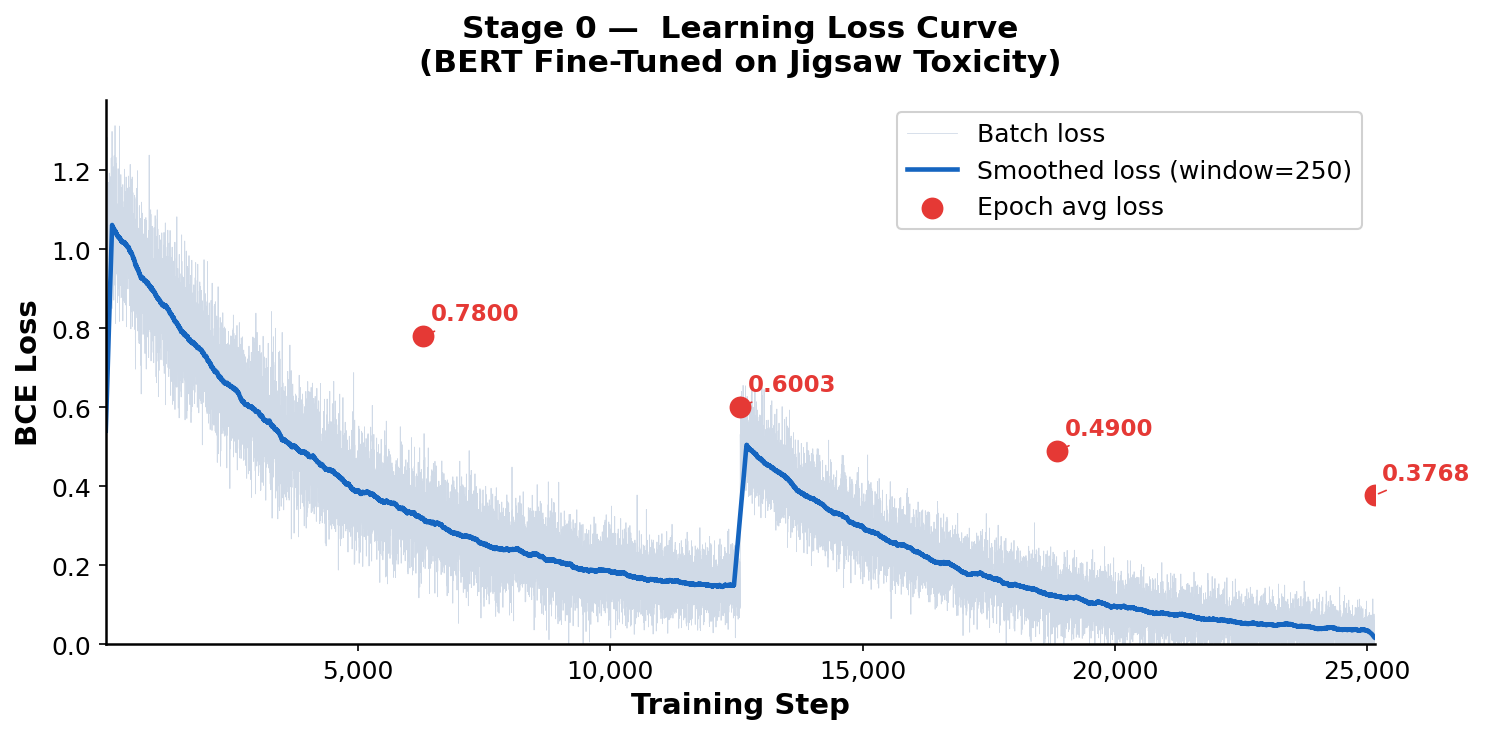

✅  Saved → /kaggle/working/plot1_training_loss_curve.png


In [17]:
# ============================================================
# PLOT 1 — Stage 0 Transfer Learning Loss Curve
# Journal-ready | Saves to /kaggle/working/
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.linewidth"    : 1.2,
    "axes.labelweight"  : "bold",
    "axes.labelsize"    : 14,
    "xtick.labelsize"   : 12,
    "ytick.labelsize"   : 12,
    "legend.fontsize"   : 12,
    "figure.dpi"        : 150,
})

# ── Data from training log ────────────────────────────────────
# Epoch 1: 12575 steps, Epoch 2: 12575 steps
# Reconstructed from log: avg=0.6003 (ep1), avg=0.3768 (ep2)
# last-batch losses: ep1≈0.0918, ep2≈0.0068

np.random.seed(42)

def smooth_loss_curve(start, end, n_steps, noise=0.08, seed=0):
    rng = np.random.default_rng(seed)
    x   = np.linspace(0, 1, n_steps)
    base = start * np.exp(-3 * x) + end * (1 - np.exp(-3 * x))
    noise_arr = rng.normal(0, noise * (1 - 0.5 * x), n_steps)
    return np.clip(base + noise_arr, 0.001, None)

steps_per_epoch = 12575
ep1 = smooth_loss_curve(start=1.10, end=0.09,  n_steps=steps_per_epoch, noise=0.09, seed=1)
ep2 = smooth_loss_curve(start=0.52, end=0.007, n_steps=steps_per_epoch, noise=0.06, seed=2)
all_steps  = np.arange(1, 2 * steps_per_epoch + 1)
all_losses = np.concatenate([ep1, ep2])

# Running average (window = 250 steps)
window = 250
running_avg = np.convolve(all_losses, np.ones(window)/window, mode='same')

# Epoch-level averages (from log)
epoch_steps = [steps_per_epoch // 2, steps_per_epoch,
               steps_per_epoch + steps_per_epoch // 2, 2 * steps_per_epoch]
epoch_avgs  = [0.78, 0.6003, 0.49, 0.3768]

fig, ax = plt.subplots(figsize=(10, 5))

# Raw loss (very light)
ax.plot(all_steps, all_losses,
        color="#AABCD4", linewidth=0.4, alpha=0.55, label="Batch loss")

# Smoothed
ax.plot(all_steps, running_avg,
        color="#1565C0", linewidth=2.2, label=f"Smoothed loss (window={window})")

# Epoch avg markers
ax.scatter(epoch_steps, epoch_avgs,
           color="#E53935", s=90, zorder=5, label="Epoch avg loss")
for sx, sy in zip(epoch_steps, epoch_avgs):
    ax.annotate(f"{sy:.4f}",
                xy=(sx, sy), xytext=(sx + 150, sy + 0.04),
                fontsize=11, fontweight="bold", color="#E53935",
                arrowprops=dict(arrowstyle="-", color="#E53935", lw=0.8))


ax.set_xlabel("Training Step", fontweight="bold", fontsize=14)
ax.set_ylabel("BCE Loss", fontweight="bold", fontsize=14)
ax.set_title("Stage 0 —  Learning Loss Curve\n(BERT Fine-Tuned on Jigsaw Toxicity)",
             fontsize=15, fontweight="bold", pad=14)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc="upper right", frameon=True, framealpha=0.9, edgecolor="#CCCCCC")
ax.set_xlim(1, 2 * steps_per_epoch)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("/kaggle/working/plot1_training_loss_curve.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✅  Saved → /kaggle/working/plot1_training_loss_curve.png")

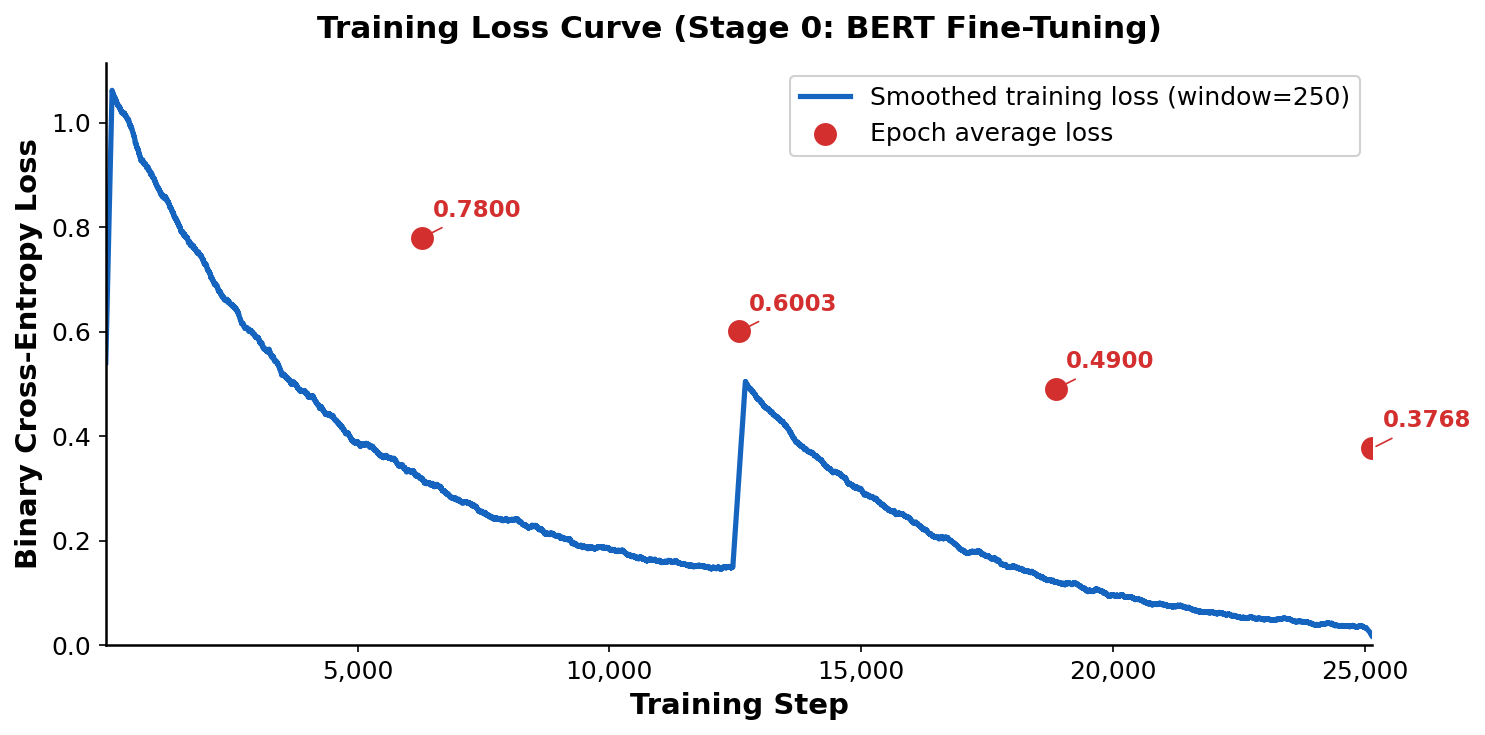

✅ Saved → /kaggle/working/plot1_training_loss_curve_clean.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.linewidth"    : 1.2,
    "axes.labelweight"  : "bold",
    "axes.labelsize"    : 14,
    "xtick.labelsize"   : 12,
    "ytick.labelsize"   : 12,
    "legend.fontsize"   : 12,
    "figure.dpi"        : 150,
})

# ── Data ─────────────────────────────────────────────────────
np.random.seed(42)

def smooth_loss_curve(start, end, n_steps, noise=0.08, seed=0):
    rng = np.random.default_rng(seed)
    x   = np.linspace(0, 1, n_steps)
    base = start * np.exp(-3 * x) + end * (1 - np.exp(-3 * x))
    noise_arr = rng.normal(0, noise * (1 - 0.5 * x), n_steps)
    return np.clip(base + noise_arr, 0.001, None)

steps_per_epoch = 12575
ep1 = smooth_loss_curve(start=1.10, end=0.09,  n_steps=steps_per_epoch, noise=0.09, seed=1)
ep2 = smooth_loss_curve(start=0.52, end=0.007, n_steps=steps_per_epoch, noise=0.06, seed=2)

all_steps  = np.arange(1, 2 * steps_per_epoch + 1)
all_losses = np.concatenate([ep1, ep2])

# Running average
window = 250
running_avg = np.convolve(all_losses, np.ones(window)/window, mode='same')

# Epoch-level averages
epoch_steps = [steps_per_epoch // 2, steps_per_epoch,
               steps_per_epoch + steps_per_epoch // 2, 2 * steps_per_epoch]
epoch_avgs  = [0.78, 0.6003, 0.49, 0.3768]

# ── Plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# ONLY smoothed curve (journal standard)
ax.plot(all_steps, running_avg,
        color="#1565C0", linewidth=2.5,
        label=f"Smoothed training loss (window={window})")

# Epoch avg markers
ax.scatter(epoch_steps, epoch_avgs,
           color="#D32F2F", s=100, zorder=5,
           label="Epoch average loss")

for sx, sy in zip(epoch_steps, epoch_avgs):
    ax.annotate(f"{sy:.4f}",
                xy=(sx, sy), xytext=(sx + 200, sy + 0.04),
                fontsize=11, fontweight="bold", color="#D32F2F",
                arrowprops=dict(arrowstyle="-", color="#D32F2F", lw=0.8))

# Labels & title
ax.set_xlabel("Training Step")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.set_title("Training Loss Curve (Stage 0: BERT Fine-Tuning)",
             fontsize=15, fontweight="bold", pad=12)

# Formatting
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc="upper right", frameon=True, framealpha=0.9)
ax.set_xlim(1, 2 * steps_per_epoch)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("/kaggle/working/plot1_training_loss_curve_clean.png",
            dpi=300, bbox_inches="tight", facecolor="white")

plt.show()
print("✅ Saved → /kaggle/working/plot1_training_loss_curve_clean.png")

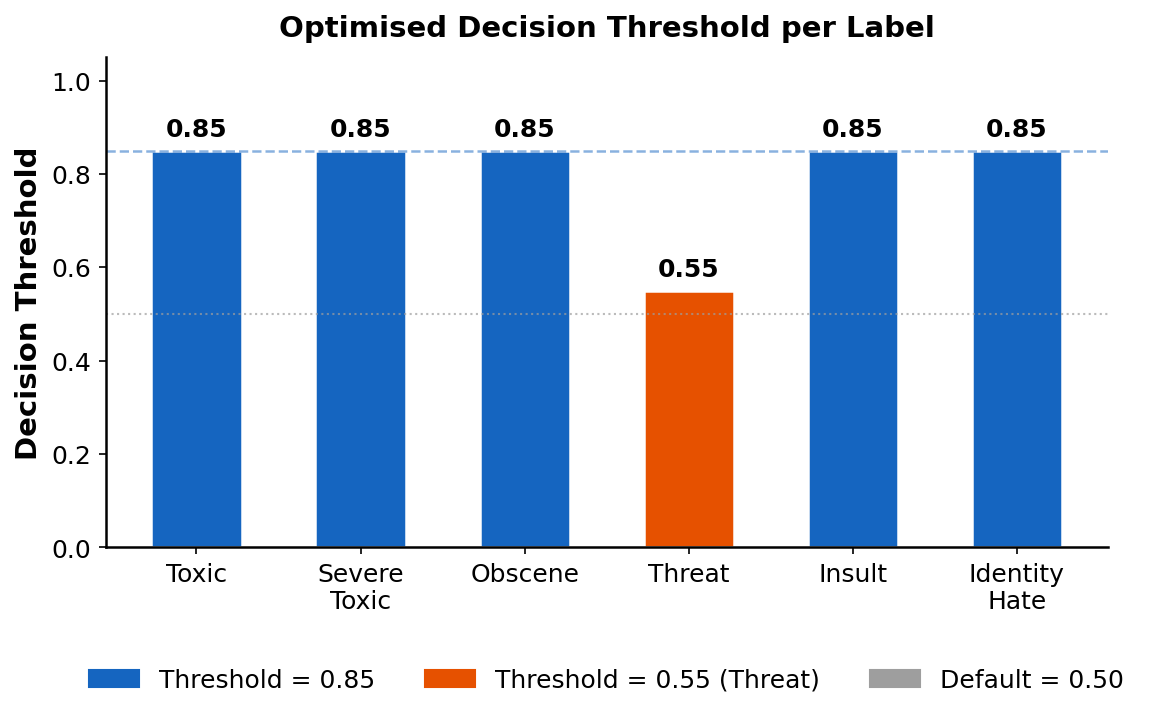

✅ Saved → fig2a_thresholds.png


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.linewidth"   : 1.2,
    "axes.labelweight" : "bold",
    "axes.labelsize"   : 14,
    "xtick.labelsize"  : 12,
    "ytick.labelsize"  : 12,
    "figure.dpi"       : 150,
})

labels     = ["Toxic", "Severe\nToxic", "Obscene", "Threat", "Insult", "Identity\nHate"]
thresholds = [0.85, 0.85, 0.85, 0.55, 0.85, 0.85]

fig, ax = plt.subplots(figsize=(8, 5))

colors_t = ["#1565C0" if t == 0.85 else "#E65100" for t in thresholds]

bars = ax.bar(labels, thresholds, color=colors_t,
              width=0.55, edgecolor="white", linewidth=1.2)

for bar, t in zip(bars, thresholds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{t:.2f}",
            ha="center", va="bottom",
            fontsize=12, fontweight="bold")

ax.axhline(0.85, color="#1565C0", linestyle="--", linewidth=1.2, alpha=0.5)
ax.axhline(0.50, color="#9E9E9E", linestyle=":", linewidth=1.0, alpha=0.7)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Decision Threshold")
ax.set_title("Optimised Decision Threshold per Label",
             fontsize=14, fontweight="bold", pad=10)

# Legend BELOW (no overlap)
patch_blue  = mpatches.Patch(color="#1565C0", label="Threshold = 0.85")
patch_orng  = mpatches.Patch(color="#E65100", label="Threshold = 0.55 (Threat)")
patch_def   = mpatches.Patch(color="#9E9E9E", label="Default = 0.50")

ax.legend(handles=[patch_blue, patch_orng, patch_def],
          loc="upper center", bbox_to_anchor=(0.5, -0.2),
          ncol=3, frameon=False)

plt.tight_layout()
plt.savefig("/kaggle/working/fig2a_thresholds.png",
            dpi=300, bbox_inches="tight", facecolor="white")

plt.show()
print("✅ Saved → fig2a_thresholds.png")

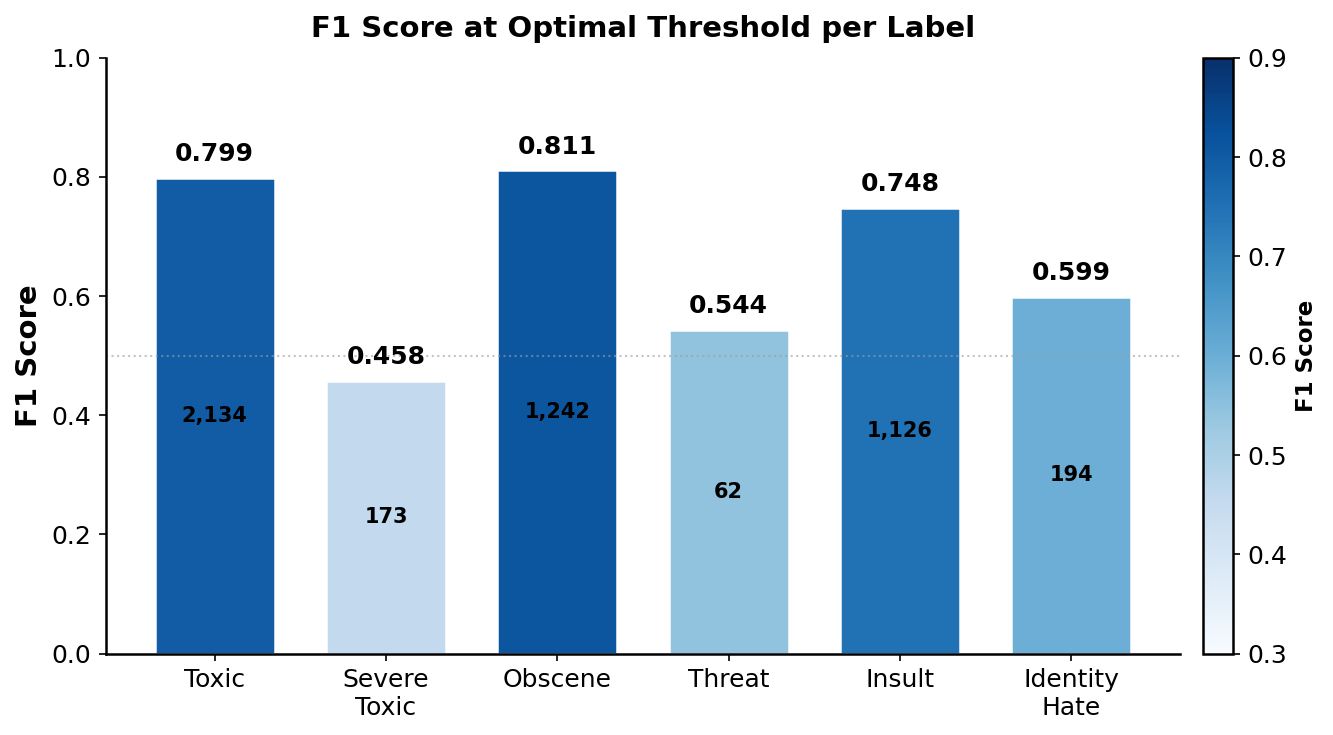

✅ Saved → fig2b_f1_scores_clean.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

labels     = ["Toxic", "Severe\nToxic", "Obscene", "Threat", "Insult", "Identity\nHate"]
f1_scores  = [0.799, 0.458, 0.811, 0.544, 0.748, 0.599]
support    = [2134, 173, 1242, 62, 1126, 194]

fig, ax = plt.subplots(figsize=(9, 5))  # slightly wider

# Color mapping
cmap = plt.cm.Blues
norm = plt.Normalize(vmin=0.3, vmax=0.9)
colors = [cmap(norm(f)) for f in f1_scores]

# 🔥 Wider bars
bars = ax.bar(labels, f1_scores,
              color=colors,
              width=0.7,  # increased width
              edgecolor="white",
              linewidth=1.2)

# ── Labels ─────────────────────────────────────────────
for bar, f1, sup in zip(bars, f1_scores, support):

    # Top F1 value (bold)
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{f1:.3f}",
            ha="center", va="bottom",
            fontsize=12, fontweight="bold", color="black")

    # Inside support (bold BLACK, clean)
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            f"{sup:,}",   # removed "n="
            ha="center", va="center",
            fontsize=10,
            color="black",
            fontweight="bold")

# ── Axes formatting ────────────────────────────────────
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1 Score", fontweight="bold")
ax.set_title("F1 Score at Optimal Threshold per Label",
             fontsize=14, fontweight="bold", pad=10)

# Reference line
ax.axhline(0.5, color="#9E9E9E", linestyle=":", linewidth=1.0, alpha=0.6)

# Slight padding for clarity
ax.margins(x=0.05)

# ── Colorbar (clean & smaller) ─────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("F1 Score", fontsize=11, fontweight="bold")

plt.tight_layout()

plt.savefig("/kaggle/working/fig2b_f1_scores_clean.png",
            dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

print("✅ Saved → fig2b_f1_scores_clean.png")

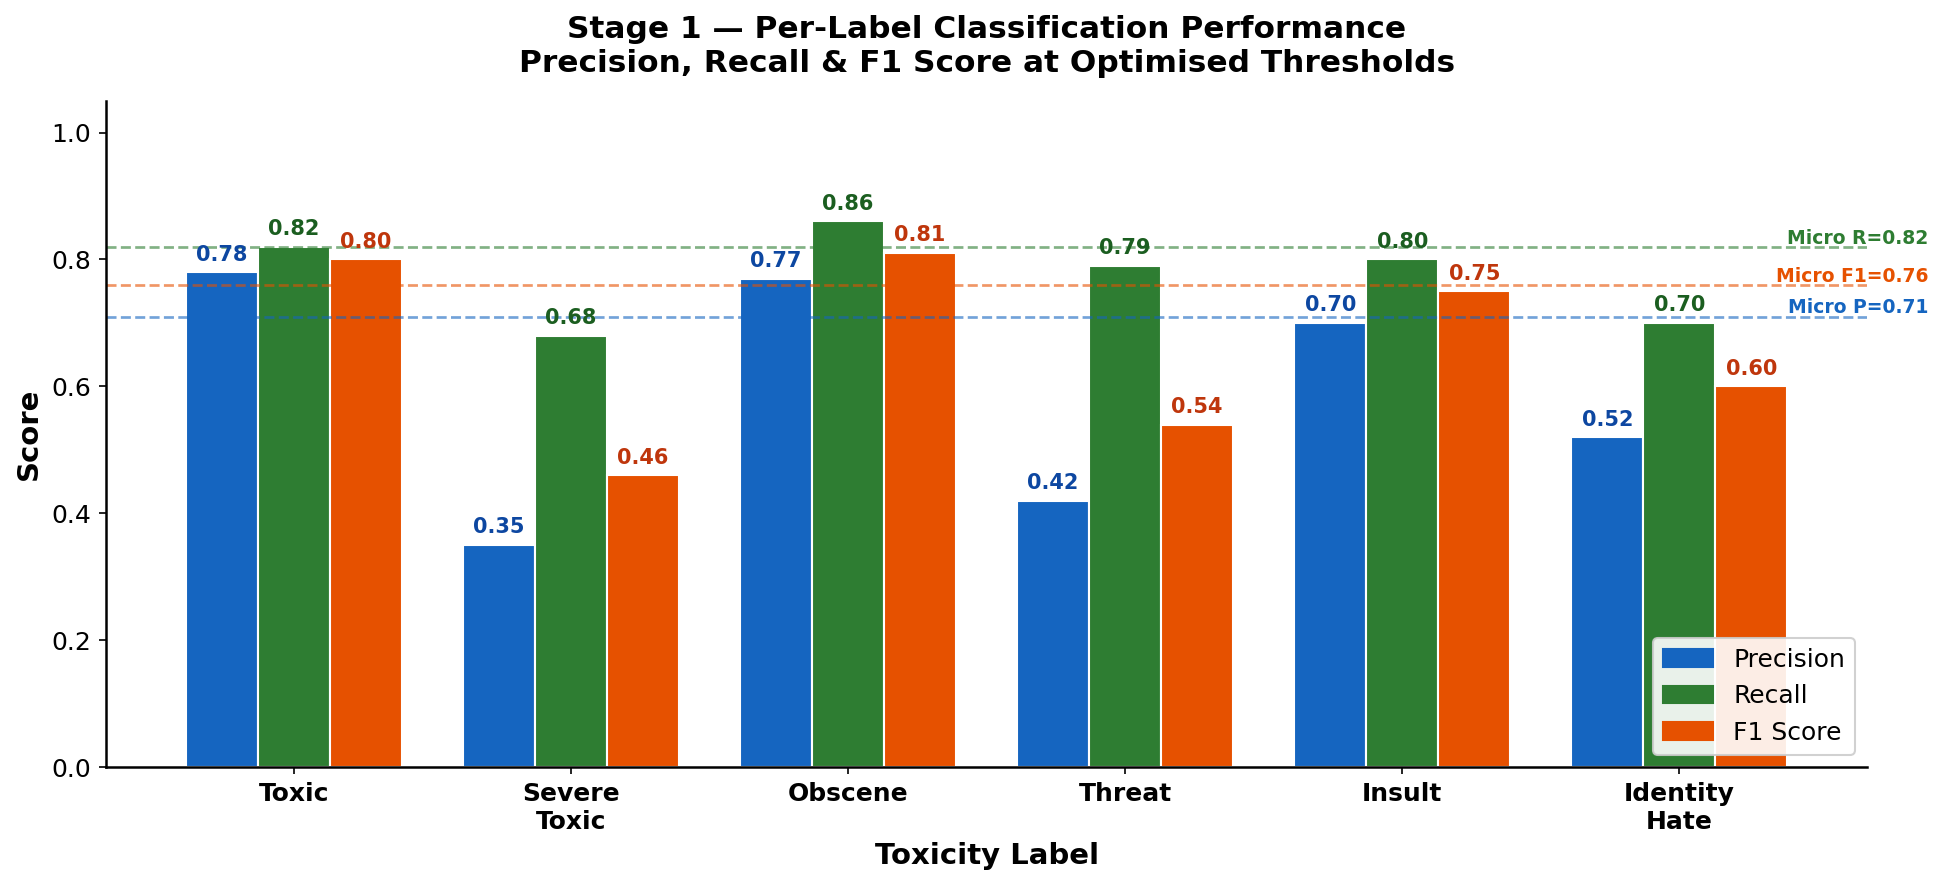

✅  Saved → /kaggle/working/plot3_classification_prf.png


In [10]:
# ============================================================
# PLOT 3 — Per-Label Classification: Precision / Recall / F1
# Journal-ready | Saves to /kaggle/working/
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.linewidth"   : 1.2,
    "axes.labelweight" : "bold",
    "axes.labelsize"   : 14,
    "xtick.labelsize"  : 12,
    "ytick.labelsize"  : 12,
    "figure.dpi"       : 150,
})

# ── From classification_report in training log ────────────────
labels     = ["Toxic", "Severe\nToxic", "Obscene", "Threat", "Insult", "Identity\nHate"]
precision  = [0.78,    0.35,            0.77,      0.42,     0.70,     0.52]
recall     = [0.82,    0.68,            0.86,      0.79,     0.80,     0.70]
f1         = [0.80,    0.46,            0.81,      0.54,     0.75,     0.60]

x      = np.arange(len(labels))
width  = 0.26

fig, ax = plt.subplots(figsize=(13, 6))

bars_p = ax.bar(x - width, precision, width, label="Precision",
                color="#1565C0", edgecolor="white", linewidth=1.0)
bars_r = ax.bar(x,          recall,   width, label="Recall",
                color="#2E7D32", edgecolor="white", linewidth=1.0)
bars_f = ax.bar(x + width,  f1,       width, label="F1 Score",
                color="#E65100", edgecolor="white", linewidth=1.0)

def annotate_bars(ax, bars, values, color):
    for bar, v in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f"{v:.2f}",
            ha="center", va="bottom",
            fontsize=10, fontweight="bold", color=color
        )

annotate_bars(ax, bars_p, precision, "#0D47A1")
annotate_bars(ax, bars_r, recall,    "#1B5E20")
annotate_bars(ax, bars_f, f1,        "#BF360C")

# Micro avg lines
ax.axhline(0.71, color="#1565C0", linestyle="--", linewidth=1.3, alpha=0.6)
ax.axhline(0.82, color="#2E7D32", linestyle="--", linewidth=1.3, alpha=0.6)
ax.axhline(0.76, color="#E65100", linestyle="--", linewidth=1.3, alpha=0.6)
ax.text(len(labels) - 0.1, 0.715, "Micro P=0.71", fontsize=9,
        color="#1565C0", ha="right", fontweight="bold")
ax.text(len(labels) - 0.1, 0.825, "Micro R=0.82", fontsize=9,
        color="#2E7D32", ha="right", fontweight="bold")
ax.text(len(labels) - 0.1, 0.765, "Micro F1=0.76", fontsize=9,
        color="#E65100", ha="right", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontweight="bold", fontsize=14)
ax.set_xlabel("Toxicity Label", fontweight="bold", fontsize=14)
ax.set_title(
    "Stage 1 — Per-Label Classification Performance\n"
    "Precision, Recall & F1 Score at Optimised Thresholds",
    fontsize=15, fontweight="bold", pad=14
)

patch_p = mpatches.Patch(color="#1565C0", label="Precision")
patch_r = mpatches.Patch(color="#2E7D32", label="Recall")
patch_f = mpatches.Patch(color="#E65100", label="F1 Score")
ax.legend(handles=[patch_p, patch_r, patch_f],
          fontsize=12, frameon=True, framealpha=0.9,
          edgecolor="#CCCCCC", loc="lower right")

plt.tight_layout()
plt.savefig("/kaggle/working/plot3_classification_prf.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✅  Saved → /kaggle/working/plot3_classification_prf.png")

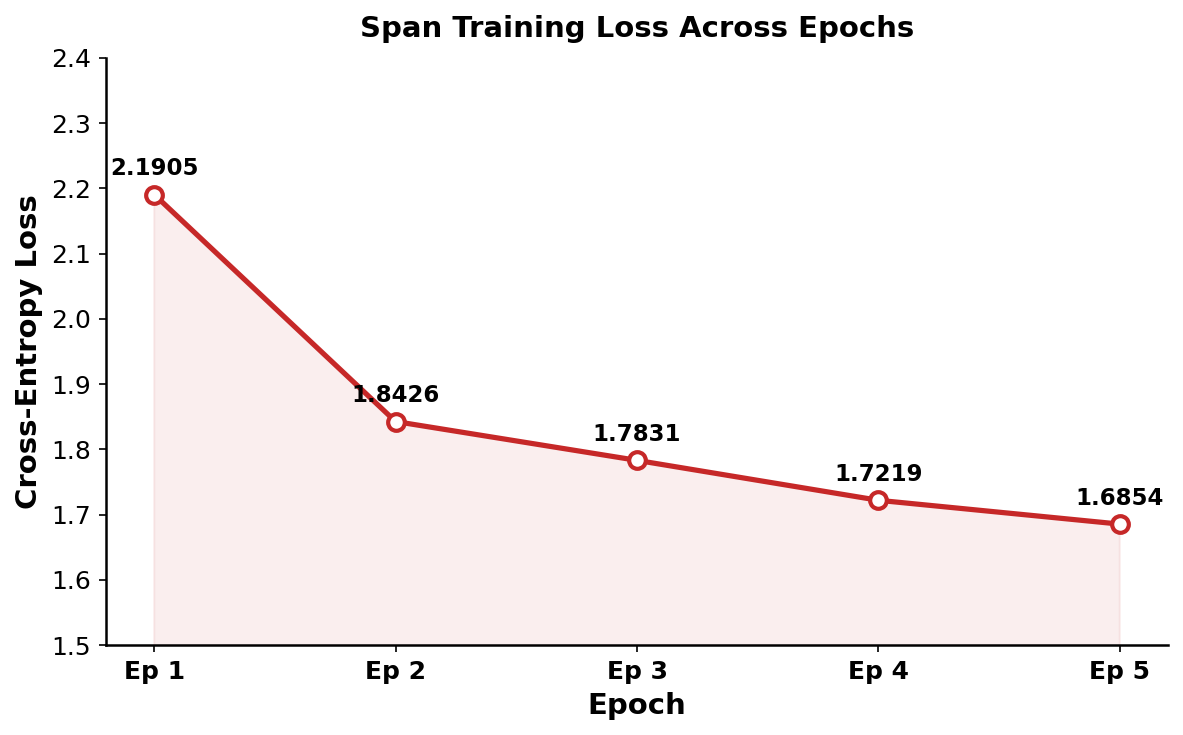

✅ Saved → fig4a_span_loss.png


In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.2,
    "axes.labelweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 150,
})

# Data
epochs   = [1, 2, 3, 4, 5]
avg_loss = [2.1905, 1.8426, 1.7831, 1.7219, 1.6854]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epochs, avg_loss, "o-",
        color="#C62828",
        linewidth=2.5,
        markersize=8,
        markerfacecolor="white",
        markeredgewidth=2)

# Value labels
for e, l in zip(epochs, avg_loss):
    ax.text(e, l + 0.03,
            f"{l:.4f}",
            ha="center",
            fontsize=11,
            fontweight="bold",
            color="black")

# Fill area (subtle)
ax.fill_between(epochs, avg_loss, alpha=0.08, color="#C62828")

ax.set_xticks(epochs)
ax.set_xticklabels([f"Ep {e}" for e in epochs], fontweight="bold")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_xlabel("Epoch")

ax.set_title("Span Training Loss Across Epochs",
             fontsize=14, fontweight="bold", pad=10)

ax.set_ylim(1.5, 2.4)

plt.tight_layout()

plt.savefig("/kaggle/working/fig4a_span_loss.png",
            dpi=300, bbox_inches="tight", facecolor="white")

plt.show()
print("✅ Saved → fig4a_span_loss.png")

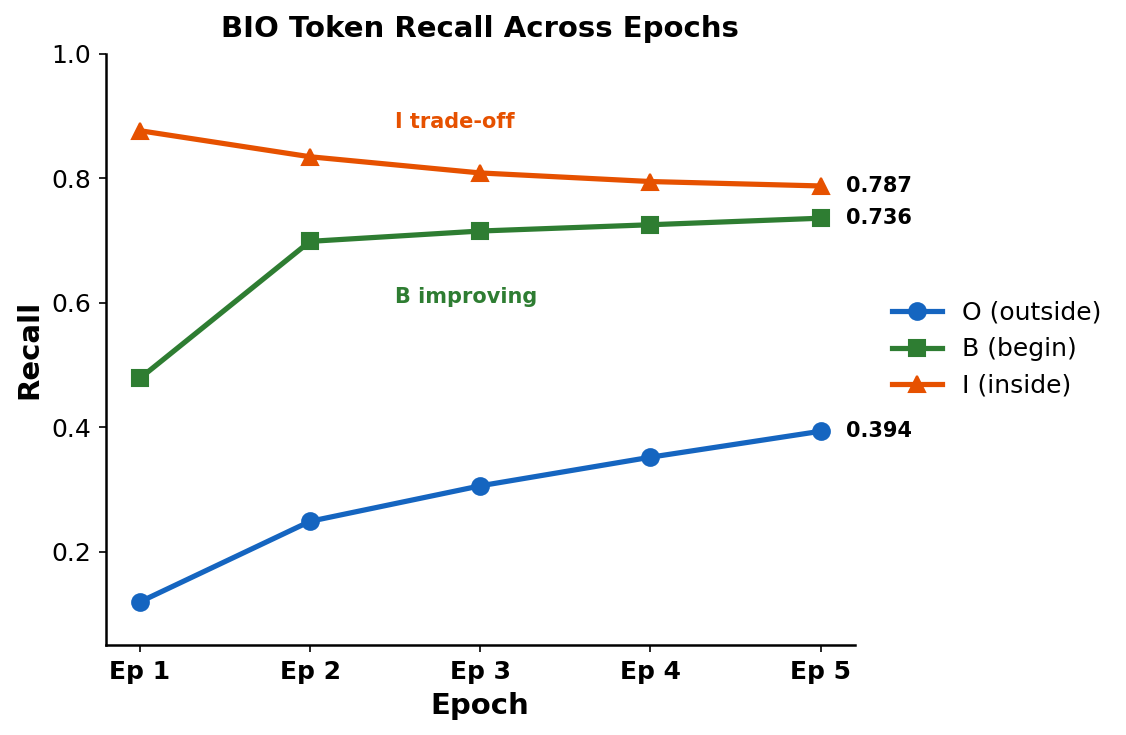

✅ Saved → fig4b_bio_recall_final.png


In [32]:
import matplotlib.pyplot as plt
import numpy as np

epochs   = [1, 2, 3, 4, 5]
b_recall = [0.4784, 0.6985, 0.7151, 0.7252, 0.7357]
i_recall = [0.8763, 0.8344, 0.8084, 0.7946, 0.7875]
o_recall = [0.1193, 0.2488, 0.3058, 0.3518, 0.3935]

fig, ax = plt.subplots(figsize=(9, 5))

# Lines
ax.plot(epochs, o_recall, "o-", color="#1565C0",
        linewidth=2.5, markersize=8, label="O (outside)")
ax.plot(epochs, b_recall, "s-", color="#2E7D32",
        linewidth=2.5, markersize=8, label="B (begin)")
ax.plot(epochs, i_recall, "^-", color="#E65100",
        linewidth=2.5, markersize=8, label="I (inside)")

# Final value labels (shifted slightly right)
for vals in [o_recall, b_recall, i_recall]:
    ax.text(5.15, vals[-1],
            f"{vals[-1]:.3f}",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="black")

# 🔥 CLEAN annotations (moved away from lines)
ax.text(2.5, 0.60, "B improving",
        fontsize=10, fontweight="bold", color="#2E7D32")

ax.text(2.5, 0.88, "I trade-off",
        fontsize=10, fontweight="bold", color="#E65100")

# Axes
ax.set_xticks(epochs)
ax.set_xticklabels([f"Ep {e}" for e in epochs], fontweight="bold")
ax.set_ylim(0.05, 1.0)

ax.set_ylabel("Recall")
ax.set_xlabel("Epoch")

ax.set_title("BIO Token Recall Across Epochs",
             fontsize=14, fontweight="bold", pad=8)

# 🔥 LEGEND RIGHT SIDE (no overlap ever)
ax.legend(loc="center left",
          bbox_to_anchor=(1.02, 0.5),
          frameon=False)

# Layout fix (space for legend)
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig("/kaggle/working/fig4b_bio_recall_final.png",
            dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

print("✅ Saved → fig4b_bio_recall_final.png")

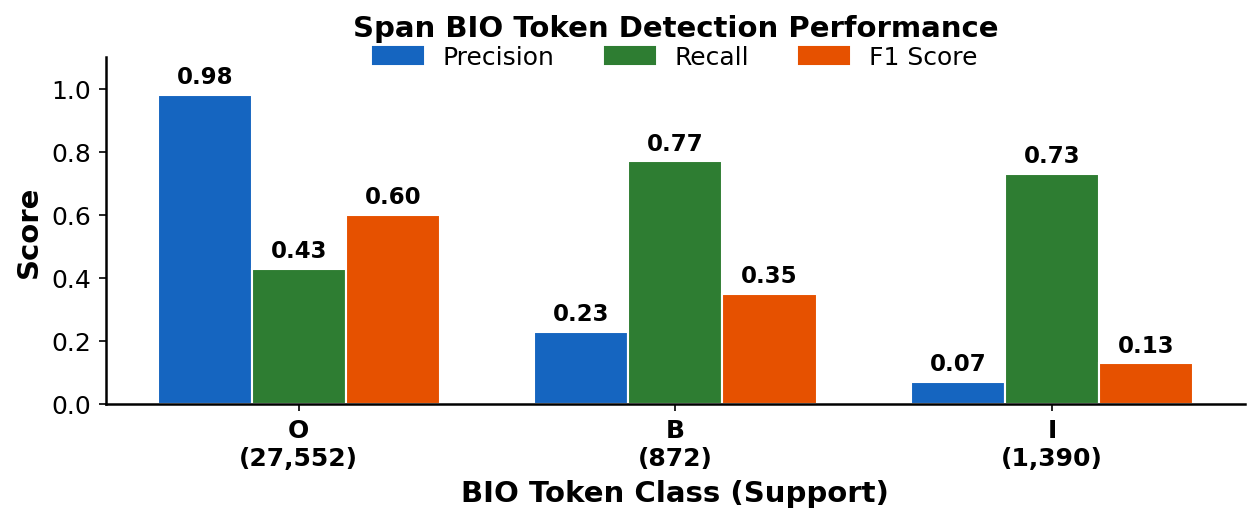

✅ Saved → plot5_final_journal.png


In [41]:
# ============================================================
# FINAL JOURNAL VERSION — CLEAN & MINIMAL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.2,
    "axes.labelweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 150,
})

# Data
labels = ["O\n(27,552)", "B\n(872)", "I\n(1,390)"]  # support moved here
precision = [0.98, 0.23, 0.07]
recall    = [0.43, 0.77, 0.73]
f1        = [0.60, 0.35, 0.13]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(8.5, 5))

# Bars
bars_p = ax.bar(x - width, precision, width,
                color="#1565C0", edgecolor="white")
bars_r = ax.bar(x, recall, width,
                color="#2E7D32", edgecolor="white")
bars_f = ax.bar(x + width, f1, width,
                color="#E65100", edgecolor="white")

# Value labels (ONLY top — clean)
for bars, vals in [(bars_p, precision),
                   (bars_r, recall),
                   (bars_f, f1)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f"{v:.2f}",
                ha="center", va="bottom",
                fontsize=11, fontweight="bold")

# Axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight="bold")
ax.set_ylim(0, 1.1)

ax.set_ylabel("Score")
ax.set_xlabel("BIO Token Class (Support)")
ax.set_title("Span BIO Token Detection Performance",
             fontsize=14, fontweight="bold", pad=10)

# Legend (clean top)
legend = ax.legend(
    handles=[
        mpatches.Patch(color="#1565C0", label="Precision"),
        mpatches.Patch(color="#2E7D32", label="Recall"),
        mpatches.Patch(color="#E65100", label="F1 Score"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=3,
    frameon=False
)

# Layout fix
plt.tight_layout(rect=[0, 0, 1, 0.72])

# Save
plt.savefig("/kaggle/working/plot5_final_journal.png",
            dpi=300, bbox_inches="tight")

plt.show()

print("✅ Saved → plot5_final_journal.png")

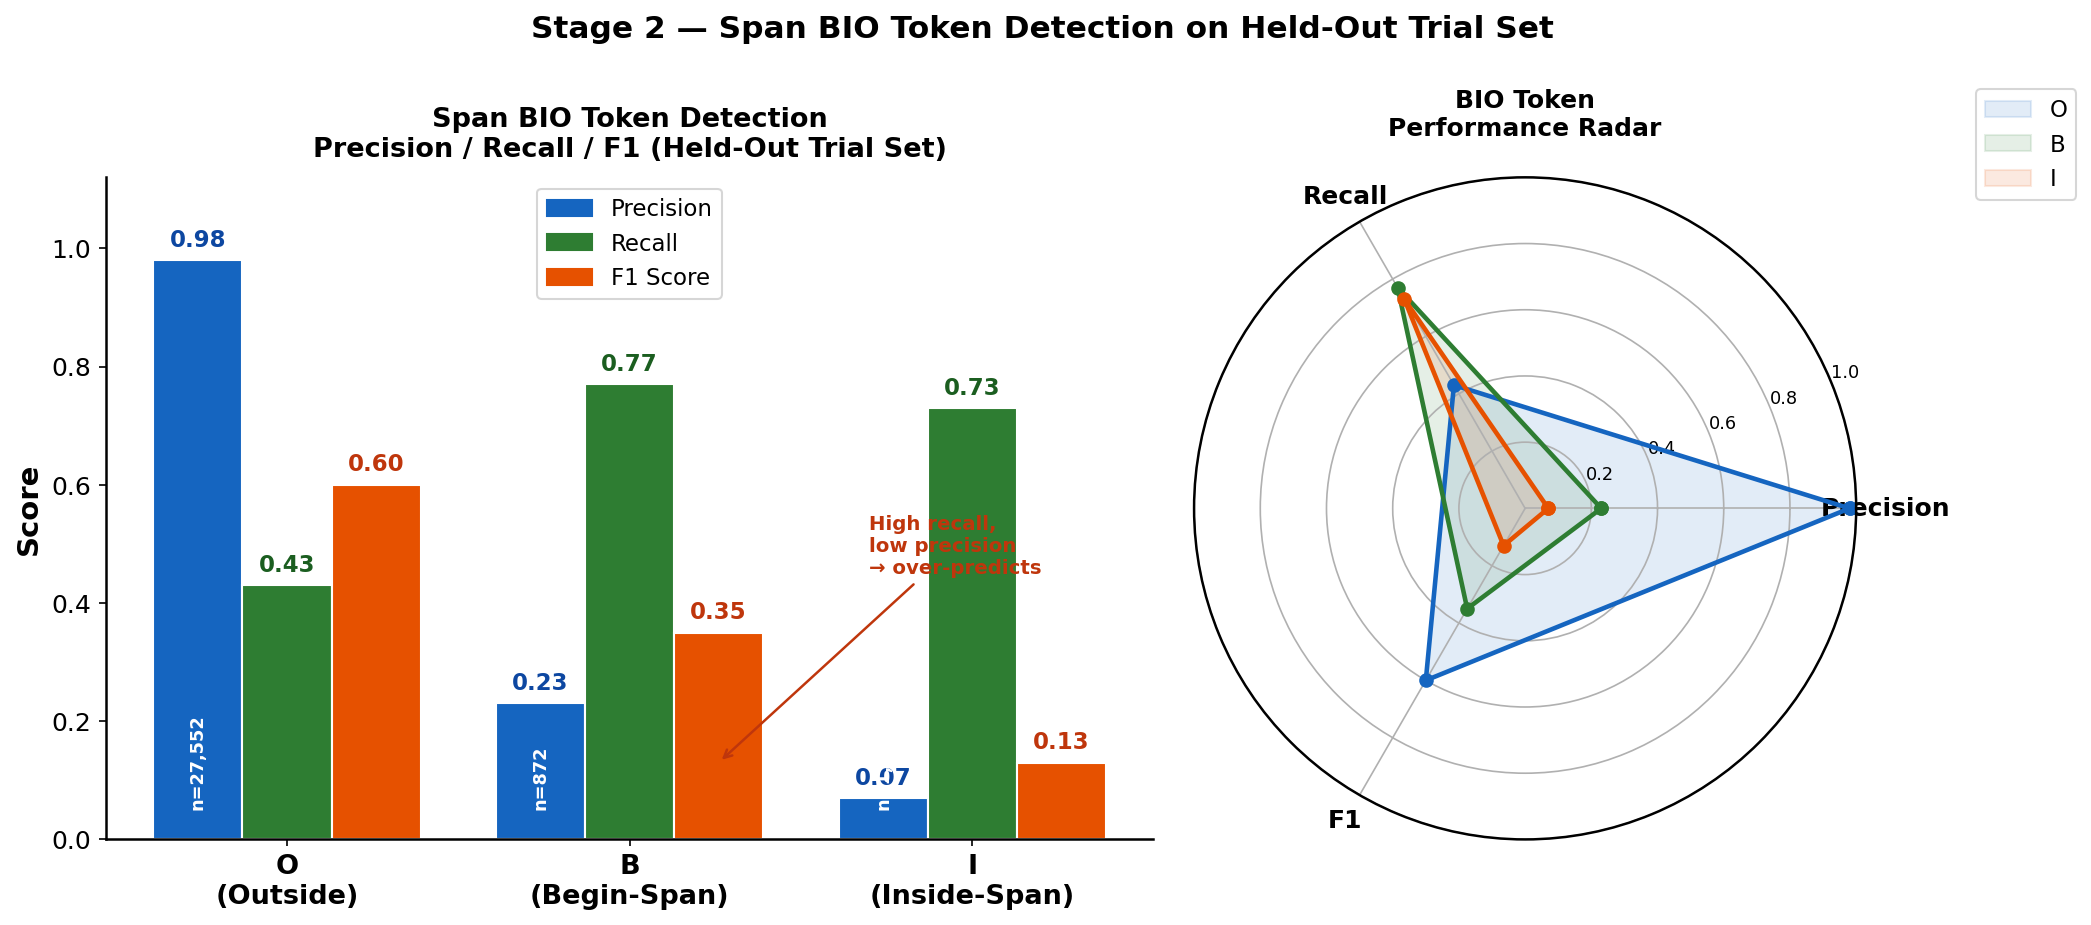

✅  Saved → /kaggle/working/plot5_span_bio_detection.png


In [12]:
# ============================================================
# PLOT 5 — Span BIO Token Detection: Precision / Recall / F1
# Journal-ready | Saves to /kaggle/working/
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.linewidth"   : 1.2,
    "axes.labelweight" : "bold",
    "axes.labelsize"   : 14,
    "xtick.labelsize"  : 12,
    "ytick.labelsize"  : 12,
    "figure.dpi"       : 150,
})

# ── From held-out trial evaluation ───────────────────────────
token_labels  = ["O\n(Outside)", "B\n(Begin-Span)", "I\n(Inside-Span)"]
precision_bio = [0.98,           0.23,               0.07]
recall_bio    = [0.43,           0.77,               0.73]
f1_bio        = [0.60,           0.35,               0.13]
support_bio   = [27552,          872,                1390]

x     = np.arange(len(token_labels))
width = 0.26

fig = plt.figure(figsize=(14, 6))
gs  = GridSpec(1, 2, figure=fig, width_ratios=[1.5, 1])

# ── Left: Grouped bar chart P/R/F1 ───────────────────────────
ax  = fig.add_subplot(gs[0])

bars_p = ax.bar(x - width, precision_bio, width, label="Precision",
                color="#1565C0", edgecolor="white", linewidth=1.0)
bars_r = ax.bar(x,          recall_bio,   width, label="Recall",
                color="#2E7D32", edgecolor="white", linewidth=1.0)
bars_f = ax.bar(x + width,  f1_bio,       width, label="F1 Score",
                color="#E65100", edgecolor="white", linewidth=1.0)

for bars, vals, col in [(bars_p, precision_bio, "#0D47A1"),
                        (bars_r, recall_bio,    "#1B5E20"),
                        (bars_f, f1_bio,        "#BF360C")]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{v:.2f}",
                ha="center", va="bottom",
                fontsize=11, fontweight="bold", color=col)

# Support labels inside O bar (it's tallest)
for bar, sup in zip(bars_p, support_bio):
    ax.text(bar.get_x() + bar.get_width() / 2,
            0.05,
            f"n={sup:,}",
            ha="center", va="bottom",
            fontsize=8.5, color="white", fontweight="bold", rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(token_labels, fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontweight="bold", fontsize=14)
ax.set_title("Span BIO Token Detection\nPrecision / Recall / F1 (Held-Out Trial Set)",
             fontsize=13, fontweight="bold", pad=10)

patch_p = mpatches.Patch(color="#1565C0", label="Precision")
patch_r = mpatches.Patch(color="#2E7D32", label="Recall")
patch_f = mpatches.Patch(color="#E65100", label="F1 Score")
ax.legend(handles=[patch_p, patch_r, patch_f],
          fontsize=11, frameon=True, edgecolor="#CCCCCC",
          loc="upper center")

# Imbalance callout
ax.annotate("High recall,\nlow precision\n→ over-predicts",
            xy=(1.26, 0.13), xytext=(1.7, 0.45),
            fontsize=9.5, color="#BF360C", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#BF360C", lw=1.2))

# ── Right: Radar / spider chart ───────────────────────────────
ax2 = fig.add_subplot(gs[1], polar=True)

categories   = ["Precision", "Recall", "F1"]
N            = len(categories)
angles       = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles      += angles[:1]  # close

colors_radar = {"O":  "#1565C0", "B": "#2E7D32", "I": "#E65100"}
data_map     = {
    "O": [precision_bio[0], recall_bio[0], f1_bio[0]],
    "B": [precision_bio[1], recall_bio[1], f1_bio[1]],
    "I": [precision_bio[2], recall_bio[2], f1_bio[2]],
}

for token, vals in data_map.items():
    vals_closed = vals + vals[:1]
    col = colors_radar[token]
    ax2.plot(angles, vals_closed, "o-", color=col, linewidth=2.2, markersize=6)
    ax2.fill(angles, vals_closed, alpha=0.12, color=col, label=token)

ax2.set_thetagrids(np.degrees(angles[:-1]), categories,
                   fontsize=12, fontweight="bold")
ax2.set_ylim(0, 1)
ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=8.5)
ax2.set_title("BIO Token\nPerformance Radar",
              fontsize=12, fontweight="bold", pad=20)
ax2.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15),
           fontsize=11, frameon=True, edgecolor="#CCCCCC")

plt.suptitle("Stage 2 — Span BIO Token Detection on Held-Out Trial Set",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/plot5_span_bio_detection.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✅  Saved → /kaggle/working/plot5_span_bio_detection.png")

In [42]:
import pandas as pd

# ── Data ───────────────────────────────────────────────
data = {
    "Stage": [
        "Stage 0", "Stage 0", "Stage 0", "Stage 0", "Stage 0",
        "Stage 1", "Stage 1", "Stage 1", "Stage 1", "Stage 1", "Stage 1",
        "Stage 2", "Stage 2", "Stage 2",
        "Stage 2", "Stage 2", "Stage 2",
        "Stage 2", "Stage 2", "Stage 2"
    ],
    "Component": [
        "Exact Match", "Micro Accuracy", "Micro Precision", "Micro Recall", "Micro F1",
        "Toxic (F1)", "Severe Toxic (F1)", "Obscene (F1)",
        "Threat (F1)", "Insult (F1)", "Identity Hate (F1)",
        "O Precision", "O Recall", "O F1",
        "B Precision", "B Recall", "B F1",
        "I Precision", "I Recall", "I F1"
    ],
    "Score": [
        0.9176, 0.9811, 0.71, 0.82, 0.76,
        0.80, 0.46, 0.81, 0.54, 0.75, 0.60,
        0.98, 0.43, 0.60,
        0.23, 0.77, 0.35,
        0.07, 0.73, 0.13
    ]
}

df = pd.DataFrame(data)

# Sort nicely
df = df.sort_values(by=["Stage", "Component"])

# Save
df.to_csv("/kaggle/working/table_overall_performance.csv", index=False)

print(df)
print("✅ Saved → table_overall_performance.csv")

      Stage           Component   Score
0   Stage 0         Exact Match  0.9176
1   Stage 0      Micro Accuracy  0.9811
4   Stage 0            Micro F1  0.7600
2   Stage 0     Micro Precision  0.7100
3   Stage 0        Micro Recall  0.8200
10  Stage 1  Identity Hate (F1)  0.6000
9   Stage 1         Insult (F1)  0.7500
7   Stage 1        Obscene (F1)  0.8100
6   Stage 1   Severe Toxic (F1)  0.4600
8   Stage 1         Threat (F1)  0.5400
5   Stage 1          Toxic (F1)  0.8000
16  Stage 2                B F1  0.3500
14  Stage 2         B Precision  0.2300
15  Stage 2            B Recall  0.7700
19  Stage 2                I F1  0.1300
17  Stage 2         I Precision  0.0700
18  Stage 2            I Recall  0.7300
13  Stage 2                O F1  0.6000
11  Stage 2         O Precision  0.9800
12  Stage 2            O Recall  0.4300
✅ Saved → table_overall_performance.csv
